# Compolsory Assignment 4: Variational Autoencoders
Please fill out the the group name, number, members and optionally the name below.

**Group number**: Group 2 \
**Group member 1**: Simen Roko Krogstie \
**Group member 2**: Kristian Mathias Røhne \
**Group member 3**: Erling Hamil Mysen \
**Group name (optional)**: The Three Musk(eteers)

# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. It concist of **<u>two tasks</u>**. At the end of each task, there are discussion questions that _must_ be answered. The assignemnt is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 

We will explore how to use autoencoder netorks using the datsets **MNIST** (Modified National Institute of Standards and Technology) dataset is a widely used benchmark in machine learning, particularly for tasks related to image classification and computer vision. It consists of 70,000 grayscale images of handwritten digits (0–9), where each image is 28x28 pixels. The dataset is split into 60,000 training examples and 10,000 testing examples.

Autoencoder is an introduction to encoder-decoder architecture. Here we will use an encoder to transform the data into an latent representation, and a decoder to project it back into the visual space.
Two main components: an **encoder** and a **decoder**.
 - The encoder takes in the input data and maps it to a lower-dimensional latent representation. It typically consists of multiple layers that gradually reduce the dimensionality of the input data, capturing its essential features. The output of the encoder is a compressed representation of the input, often referred to as a code or latent vector.
 - The decoder, on the other hand, takes the code from the encoder and reconstructs the original data from it. It mirrors the architecture of the encoder by gradually expanding the code back to the original dimensionality. The output of the decoder is a reconstruction of the input data, which ideally should closely resemble the original input.

<div>
<img src="https://tikz.net/janosh/autoencoder.png" width="300"/>
<div>

---

### **Task 1**
- Load the MNIST dataset.
	- > (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
	- Normalize the images to have pixel values between 0 and 1.
- Build an autoencoder model.
	- The encoder should compress the images into a lower-dimensional latent space.
	- The decoder should reconstruct the images from the latent space.
	- The intermediat layers can either be linear or convolutional.
- Train the autoencoder.
	- Use `binary-cross-entropy` loss function for _reconstruction_ (i.e. target value = input value)
	- You can choose optimizer freely (Adam is recommended).
- Visualize the reconstructed images.
	- _Compare_ original and reconstructed images.
- Visualize the latent space
	- Use PCA to visualize the 2d-latent space.
	- Use the digit as labels
- Answer the discussion questions

### Import of libraries

In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras.backend as K

from keras.datasets import mnist
from keras.models import Model
from keras.layers import Input, Conv2D, Dense, Conv2DTranspose, UpSampling2D, MaxPooling2D, Flatten, Reshape
from keras.optimizers import Adam

from sklearn.decomposition import PCA

### Loading and preprocessing data

In [118]:
# Loading data partitioned in train and test
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizing images to pixel values between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshaping data making it compatible with convolutional layers
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

In [119]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

### Building Autoencoder

In [120]:
# Defining dimension of latent space
latent_dim = 64

# Defining the encoder
encoder_input = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Flatten()(x)

# Defining the latent space
latent_space = Dense(latent_dim, activation='relu')(x)

# Initializing the encoder
encoder = Model(encoder_input, latent_space, name='encoder')

In [121]:
# Defining the decoder
decoder_input = Input(shape=(latent_dim,))

x = Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoder_output = Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)

# Initializing the decoder
decoder = Model(decoder_input, decoder_output, name='decoder')

In [122]:
ae_input = encoder_input
encoded_img = encoder(ae_input)
decoded_img = decoder(encoded_img)

autoencoder = Model(ae_input, decoded_img, name='autoencoder')

### Compiling and training of Autoencoder

In [123]:
# Compiling the Autoencoder
autoencoder.compile(
    optimizer = Adam(),
    loss = 'binary_crossentropy'
)

# Training the Autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs = 20,
    batch_size = 256,
    shuffle = True,
    validation_data =(X_test, X_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - loss: 0.3099 - val_loss: 0.1233
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - loss: 0.1146 - val_loss: 0.0978
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - loss: 0.0958 - val_loss: 0.0898
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0901 - val_loss: 0.0867
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - loss: 0.0875 - val_loss: 0.0849
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0853 - val_loss: 0.0833
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0839 - val_loss: 0.0825
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0824 - val_loss: 0.0815
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0819 - val_loss: 0.0807
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - loss: 0.0813 - val_loss: 0.0802
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - loss: 0.0808 - val_loss: 0.0800
Epoch 12/20
235/235 ━━━━━━━

### Visualizing the reconstructed images

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


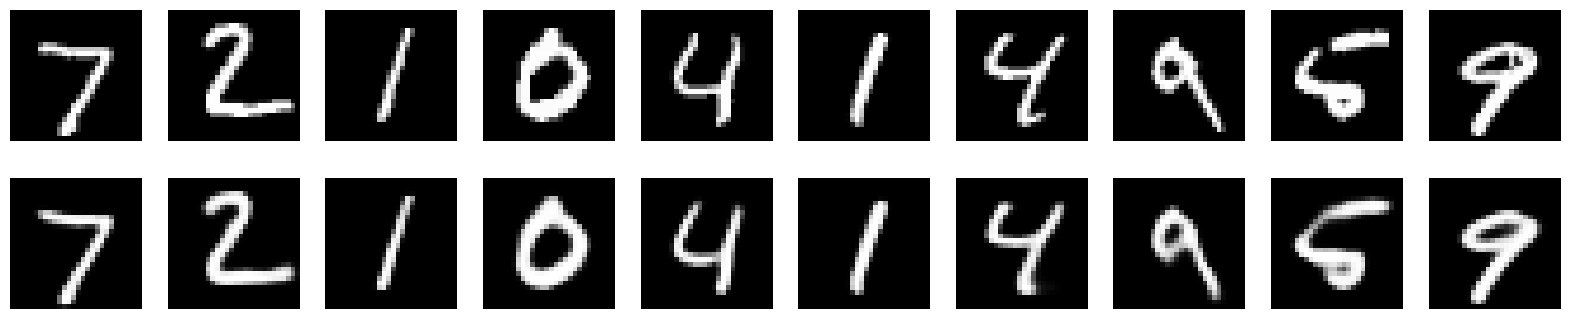

In [124]:
# Reconstructing the images
reconstructed_images = autoencoder.predict(X_test)

# Displaying a sample of reconstructed images comapred to the orginal ones
# Number of samples to display
n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # Display orginal images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Display reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

### Visualizing PCA-projection of latent space

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


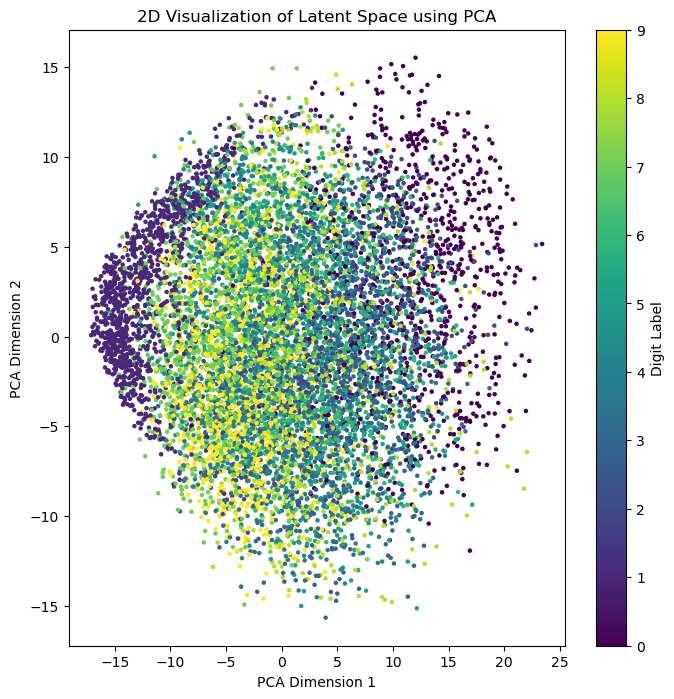

In [125]:
# Encoding the testset into the latent space
latent_representation = encoder.predict(X_test)

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

# Plotting the 2D latentspce with labels
plt.figure(figsize=(8, 8))
plot = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test, cmap='viridis', s=5)
plt.colorbar(plot, label='Digit Label')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.title('2D Visualization of Latent Space using PCA')
plt.show()

**Discussion**
1. Why do we normalize the pixel values of the images?
2. How does the size of the latent space affect the reconstructed images?
3. Can autoencoders be used for noise reduction? How?

**Answer 1:** \
We normalize the pixel values in the images because with pixel values in the range 0-1, the model will treat the pixel values with equal importance, improving the generalization. Also, when centering pixel values the model needs less adjustments of the weights for a better generalization. In addition, we mitigate the vanishing/exploding gradient problem, because normalized values keep the gradients in a managebale range. 

**Answer 2:** \
The size of the latent space determines how much information the model retains from the orignal image. With a small latent space, the model stores only the most essential features, and the reconstructed images can be blurry or abstract. With a big latent space, the model stores much more information, inwich may result in the model memorizing the input data, and therefor not generalize well. 

**Answer 3:** \
Autoencoders can be used for noise reduction. That is, Autoencoders learn the essential patterns in images, which does not include noise. Therefore, it will not remember the noise when reconstructing the image.

___
### **Task 2**

In contrast to simple autoencoders, which aim to learn a deterministic mapping from input data to a compressed latent space and back, **Variational Autoencoders (VAEs)** introduce a probabilistic approach to the latent space. While simple autoencoders can reconstruct data effectively, they are not inherently capable of generating new, realistic data samples. VAEs, on the other hand, are designed for _both reconstruction and generation_ of novel data samples, making them highly useful for generative modeling tasks.

**Why VAEs?** A simple autoencoder maps input data to a fixed point in the latent space, meaning that each input has a single corresponding latent vector. While this approach works well for compression and reconstruction, it lacks the ability to generalize and generate new data points because the latent space is not continuous or well-structured.

In contrast, a Variational Autoencoder treats the latent space probabilistically. Instead of mapping each input to a single point, it maps inputs to a distribution (typically a Gaussian distribution) in the latent space. This probabilistic treatment allows for the generation of new samples by sampling from the learned distribution, thus enabling the model to create *new*, unseen data points that resemble the training data.

**How VAEs Work?** In a VAE, the _encoder_ maps the input data to <u>two</u> vectors: a _mean vector_ and a _variance (or log variance) vector_ (in contrast to one as in a traditional AE). These vectors representing a Gaussian distribution in the latent space. Instead of encoding to a fixed point, the model <u>samples</u> a latent vector from this distribution, using these mean and variance parameters. This sampling introduces variability, allowing the VAE to explore different parts of the latent space and generate diverse outputs.

The _decoder_ then reconstructs the data by decoding from the sampled latent vector, which can either come from the encoded input or be randomly generated. This process makes VAEs ideal for generating novel data samples in applications like image generation.

**The loss function?** The loss function plays a crucial role in training the model to both reconstruct input data and ensure that the latent space is properly structured. The VAE loss function consists of two main components:

1. Reconstruction Loss: Measures how well the VAE is able to reconstruct the input data from the latent space. Typically, this is computed using binary cross-entropy (for normalized image data) or mean squared error (for continuous data). For images, binary cross-entropy is often used.

$$\mathcal{L}{\text{reconstruction}}(x, \hat{x}) = - \sum{i=1}^{N} \left[ x_i \log(\hat{x}_i) + (1 - x_i) \log(1 - \hat{x}_i) \right]$$

Where:
$x_i$  is the original data point (e.g., pixel value).
$\hat{x}_i$  is the reconstructed data point.
$N$  is the number of data points or pixels.

2. KL Divergence Loss: is used to ensure that the learned latent distribution  $q(z|x)$, parameterized by  $\mu$  and  $\sigma^2$, is close to a standard normal distribution  $p(z) = \mathcal{N}(0, I)$.

$$\mathcal{L}{\text{KL}}(q(z|x) \parallel p(z)) = \frac{1}{2} \sum{j=1}^{d} \left( 1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2 \right)$$
Where:
 $\mu_j$  is the mean of the latent variable distribution. $\sigma_j^2$  is the variance of the latent variable distribution. $d$  is the dimensionality of the latent space.

_Total Loss Function_ The total loss function for a VAE is the sum of the reconstruction loss and the KL divergence loss:
$$\mathcal{L}{\text{VAE}} = \mathcal{L}{\text{reconstruction}} + \mathcal{L}_{\text{KL}}$$


**The Role of KL Divergence** A crucial aspect of training VAEs is ensuring that the latent space is well-structured and that the learned distributions align with a _prior distribution_ (typically a standard normal distribution). This is where the _Kullback-Leibler (KL) divergence loss_ comes in. KL divergence measures how different the learned distribution is from the desired prior distribution. By minimizing KL divergence during training, the VAE ensures that the latent space follows a continuous, smooth distribution, making it easier to generate realistic new samples by sampling from this space.

In summary, VAEs combine the strengths of autoencoders for reconstruction with a probabilistic latent space, enabling the generation of new data samples and ensuring smooth interpolation within the latent space through the use of KL divergence. This combination makes VAEs a powerful generative model in unsupervised learning tasks.

<div>
<img src="https://tikz.net/janosh/vae.png" width="350"/>
<div>

Run the following code

In [126]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K

In [127]:
# Load the MNIST dataset.
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = x_test.astype('float32') / 255.0
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [128]:
latent_dim = 2  # Dimensionality of the latent space (small for simplicity)
input_shape = (28, 28, 1)  # Input image shape

In [129]:
# We define the encoder in a similar way as the autoencoder
input_img = layers.Input(shape=input_shape)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)

In [130]:
# However, instead of a single output layer to the latent space, we have two output layers (latent space parameters: mean (mu) and log variance (log_var))
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [131]:
# We define a sampling function to sample from the latent space, which introduces stochasticity in the model and helps in training (as it still alows gradients to flow backwards)
# Sampling function
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=K.shape(z_mean), mean=0., stddev=1.0)
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [132]:
# There are multiple ways to sample from the latent space, here I introduce a Lambda layer, which allows to use arbitrary functions as layers in the model
# Note the output shape of the Lambda layer; we are returning the (sampled) latent space, and the learned parameters (mean and log variance)- these are used in the loss function
z = layers.Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

In [133]:
# The decoder is defined in the same way as the autoencoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoded_img = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)

In a Variational Autoencoder (VAE), adjusting the weight of the KL divergence loss controls the balance between data reconstruction accuracy and latent space regularization. Increasing the weight encourages a more structured and continuous latent space but may reduce reconstruction quality, while decreasing it improves reconstruction but risks losing meaningful structure in the latent space.

In [134]:
#KL divergence loss weight. This is a hyperparameter that can be tuned, run ALL cells below to see the effect of different values.
# This is the value you should experiment with
KL_weight = 1.0

In [135]:
# Having build our layers, we can now define the models
encoder = Model(input_img, [z_mean, z_log_var, z], name='encoder')
decoder = Model(decoder_input, decoded_img, name='decoder')

# VAE model that connects the encoder and decoder
vae_output = decoder(encoder(input_img)[2])
vae = Model(input_img, vae_output, name='vae')

In [136]:
class KLDivergenceLayer(layers.Layer):
    """Custom layer to calculate KL Divergence loss."""

    def __init__(self, weight, **kwargs):
        super(KLDivergenceLayer, self).__init__(**kwargs)
        self.weight = weight

    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = -0.5 * K.sum(kl_loss, axis=-1)
        return K.mean(self.weight * kl_loss) 

def vae_loss(input_img, vae_output):
    """VAE loss function."""
    reconstruction_loss = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(K.flatten(input_img), K.flatten(vae_output))
    )
    reconstruction_loss *= 28 * 28
    
    # Access z_mean and z_log_var from the encoder output
    z_mean, z_log_var, _ = encoder(input_img)  # Assuming 'encoder' is a global variable

    # Instantiate the custom layer
    kl_loss_layer = KLDivergenceLayer(weight=KL_weight)  
    kl_loss = kl_loss_layer([z_mean, z_log_var])  # Pass z_mean, z_log_var to the layer

    # Rename the variable storing the total loss to avoid conflict with the function name
    total_vae_loss = K.mean(reconstruction_loss + kl_loss)  
    return total_vae_loss

In [137]:
# Train the VAE
vae.compile(optimizer='adam', loss=vae_loss)

vae.fit(x=x_train,y=x_train, epochs=5, batch_size=128, validation_data=(x_test, x_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - loss: 268.6811 - val_loss: 193.7671
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 189.7155 - val_loss: 174.7996
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 172.7689 - val_loss: 167.9312
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 167.2455 - val_loss: 164.7339
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 164.4746 - val_loss: 162.7849


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

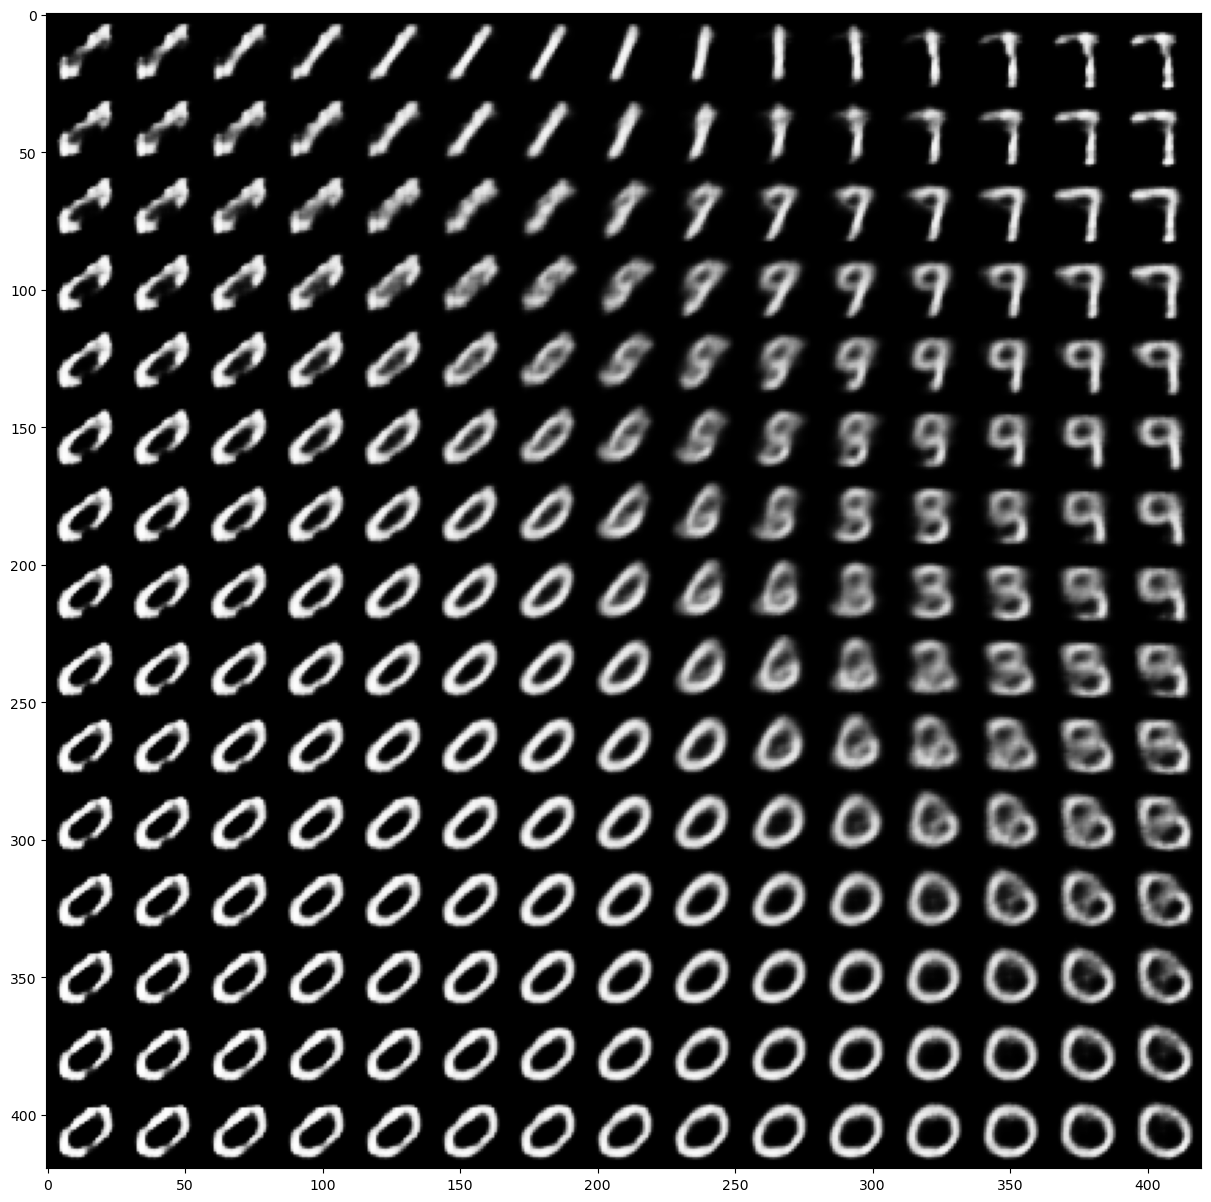

In [138]:
# Run this visualisation code after training the VAE to answere the discussion questions.
import matplotlib.pyplot as plt

def plot_latent_space(decoder, n=15, figsize=15):
    """Plots a grid of digits decoded from the VAE's latent space."""
    scale = 2.0
    figure = np.zeros((28 * n, 28 * n))
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            digit = x_decoded[0].reshape(28, 28)
            figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap='Greys_r')
    plt.show()

# Plot latent space
plot_latent_space(decoder)

**Discussion**

Tips; refer to the visualization above and the loss output from your training cell (make sure verbose is set to 1 or 2). to answer the questions.

1. Adjust the weight of the KL divergence term in the VAE loss function (e.g., set it to 0.1, 1, and 5). Run the model with each weight setting and observe the results.
2. Based on your observations, discuss how each change in the KL weight affected the VAE’s performance. Were the effects consistent with your expectations, and why or why not? Consider both the quality of the reconstructions, the loss values, and the continuity of the latent space in your answer.

___

The effects of the different weight settings was as we expected. With the KL_weight = 0.1 we got high quality reconstructions, but with a poorly structured latent space. The losses were also higher due to less regularization. 
With the KL_weight = 1.0 we got a more balanced latent space and reconstructions. The losses got also lower due to the incresae in regularization. With the KL_weight = 5.0 the latent space got overly smooth with blurry reconstructions. The losses also arised, now indicating over-regularization. 